# SMOTE (Synthetic Minority Oversampling Technique)

## SMOTE (Synthetic Minority Oversampling Technique) is a technique used in Machine learning to address imbalanced datasets. Where the minority class has significantly fewer instances then the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.

In [4]:
## SMOTE is an example of UP Sampling Method 

In [5]:
# so in order to increase the variance , we can specifically do .. we can use a interpolating techniques 
# interpolating basically means we are creating our own synthetic data.
# so here what SMOTE does is that it tries to join the two nearest point, and then it tries to add the data points similarly in the line .
# after this it goes and jpin the next two nearest point and then it tries to create a new data points in this line .
# so like this the data will be created additionally.
# so now the data that is getting created it also has variance ..

In [6]:

from sklearn.datasets import make_classification # this make_classification actually helps 
# you to create a binary classification or multi-class classification 

In [7]:
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,weights=[0,90],random_state=12)

In [8]:
import pandas as pd 
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-1.267359,0.779033,1
1,-0.914085,1.120104,1
2,-1.447578,0.173241,1
3,-2.023284,-0.428945,1
4,-1.222044,0.178239,1


In [9]:
final_df['target'].value_counts()

target
1    997
0      3
Name: count, dtype: int64

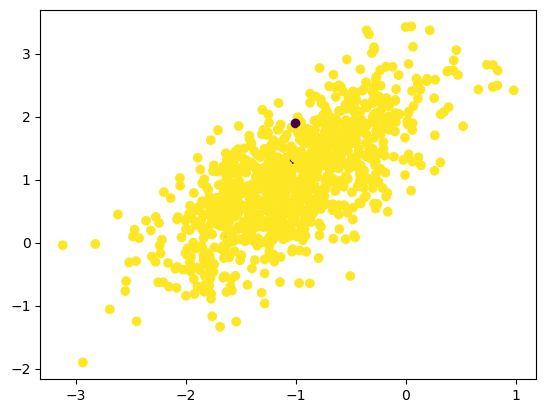

In [10]:
import matplotlib.pyplot as plt 
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [40]:
## here now we will use SMOTE 
# for using SMOTE we will use one library called as IMB learn Imbalanced learn
# it is not here so i will install that 
! pip install imblearn
%pip install --upgrade scikit-learn imbalanced-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.2 MB 1.1 MB/s eta 0:00:08
   ---------------------------------------- 0.1/8.2 MB 1.2 MB/s eta 0:00:07
    --------------------------------------- 0.1/8.2 MB 1.2 MB/s eta 0:00:07
    --------------------------------------- 0.2/8.2 MB 1.1 MB/s eta 0:00:08
   - -------------------------------------- 0.3/8.2 MB 1.1 MB/s eta 0:00:08
   - -------------------------------------- 0.3/8.2 MB 1.2 MB/s eta 0:00:07
   - -------------------------------------- 0.3/8.2 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.4/8.2 MB 1.1 MB/s eta 0:00:08
   -- ------------------------------------- 0.5/8.2 MB 1.1 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.2 MB 1.1 MB/s eta 0:00:07
   -- ------------------------------------- 0.6/8.2 MB 1.1 MB/s eta 0:00:07
   --- ------------------------------------ 0.6/8.2 MB 1.1 MB/s eta 0:00:07
   --- ------------

  You can safely remove it manually.


In [11]:
from imblearn.over_sampling import SMOTE 

In [13]:
oversample = SMOTE(k_neighbors=2, random_state=42)

X, y = oversample.fit_resample(
    final_df[['f1', 'f2']],
    final_df['target']
)

In [14]:
X.shape

(1994, 2)

In [15]:
y.shape

(1994,)

In [16]:
## from the above , before the majority had 997 with it now it has got to increased to 997with respect to 0.
# it has basically oversampled using the SMOTE Technique.

In [18]:
y==0 ## it will tell how many 0's 

0       False
1       False
2       False
3       False
4       False
        ...  
1989     True
1990     True
1991     True
1992     True
1993     True
Name: target, Length: 1994, dtype: bool

In [20]:
y[y==0] # here it only shows the datapoints where it is 0

154     0
461     0
770     0
1000    0
1001    0
       ..
1989    0
1990    0
1991    0
1992    0
1993    0
Name: target, Length: 997, dtype: int32

In [23]:
len(y[y==0]) # it basically tells how many 0's have in our dataset 

997

In [24]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

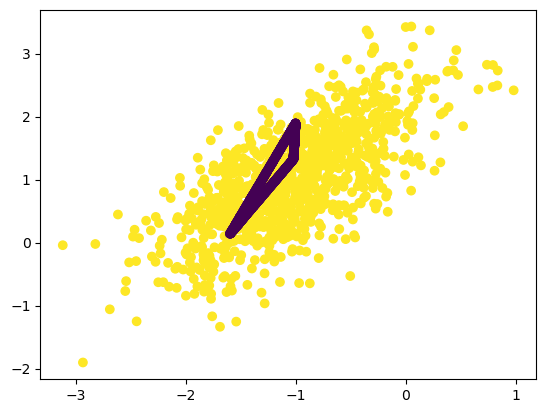

In [26]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])